# 🤖 Notebook 05 — Modeling: Anomaly Detection & Crisis Classification
## Early Warning System Krisis Pariwisata Bali — BaliGuard

Notebook ini membangun **dua model machine learning**:
1. **Isolation Forest** — anomaly detection (unsupervised), mendeteksi bulan anomali tanpa perlu label
2. **Random Forest Classifier** — klasifikasi level krisis (supervised), memprediksi AMAN/WASPADA/SIAGA/KRISIS

Dilengkapi **SHAP** untuk explainability — fitur mana yang paling berkontribusi ke prediksi krisis.

**Input:** `data/final/master_dataset_clean.parquet`  
**Output:** `data/final/model_isolation_forest.pkl`, `data/final/model_random_forest.pkl`, `data/final/predictions_final.csv`

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.pipeline import Pipeline
import joblib
import os

# SHAP
try:
    import shap
    print('✅ SHAP tersedia')
except ImportError:
    print('⚠️  SHAP belum terinstall — jalankan: pip install shap')

print('✅ Semua library berhasil diimport')
print(f'Pandas: {pd.__version__} | Numpy: {np.__version__}')

✅ SHAP tersedia
✅ Semua library berhasil diimport
Pandas: 2.3.3 | Numpy: 2.2.6


## 2. Load Dataset

In [2]:
# Load master dataset
df = pd.read_parquet('data/final/master_dataset_clean.parquet')

print('=== DATASET OVERVIEW ===')
print(f'Shape: {df.shape}')
print(f'Periode: {df["month"].min()} → {df["month"].max()}')
print()
print('Distribusi Crisis Level:')
dist = df['crisis_level'].value_counts()
for level, count in dist.items():
    pct = count/len(df)*100
    bar = '█' * int(pct/2)
    print(f'  {level:8s}: {count:3d} ({pct:.1f}%) {bar}')
print()
print('Missing values per fitur:')
nulls = df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else '  Tidak ada null ✅')

=== DATASET OVERVIEW ===
Shape: (192, 40)
Periode: 2009-01 → 2024-12

Distribusi Crisis Level:
  WASPADA : 147 (76.6%) ██████████████████████████████████████
  SIAGA   :  33 (17.2%) ████████
  AMAN    :   7 (3.6%) █
  KRISIS  :   5 (2.6%) █

Missing values per fitur:
tpk_change_mom         1
tpk_ma3                2
wisman_growth_mom      3
wisman_growth_yoy     12
wisman_ma3             2
wisman_ma6             5
wisman_zscore         11
usd_volatility_3m      2
usd_change_mom         1
bali_share_change      1
wisman_lag_1           1
wisman_lag_3           3
tpk_lag_1              1
sentiment_lag_1        1
wisman_trend_3m        2
sentiment_trend_3m     2
usd_trend_3m           2


## 3. Feature Selection & Preprocessing

In [3]:
# Fitur utama untuk modeling
# Dipilih berdasarkan: variasi tinggi, coverage ≥94%, relevansi domain
# ✅ REVISED: ditambah lag features dari NB04 FINAL

FEATURES_CORE = [
    # Kunjungan wisatawan
    'wisman_growth_mom',    # perubahan MoM
    'wisman_growth_yoy',    # perubahan YoY
    'wisman_zscore',        # anomali z-score
    # Ekonomi
    'usd_idr_avg',          # kurs USD/IDR
    'usd_volatility_3m',    # volatilitas kurs
    'usd_change_mom',       # perubahan kurs MoM
    # Hotel
    'tpk_bintang',          # tingkat hunian bintang
    'tpk_change_mom',       # perubahan TPK
    # Makro
    'inflasi_processed',    # inflasi Bali
    'bali_share_pct',       # pangsa wisman nasional
    # Sentimen
    'avg_sentiment_monthly',# rata-rata sentimen ulasan
    # Konteks
    'month_num',            # bulan (musiman)
    'is_peak_season',       # Juli/Agustus/Desember
]

# Lag & trend features (tersedia setelah NB04 FINAL dijalankan)
FEATURES_LAG = [
    'wisman_lag_1',         # wisman 1 bulan lalu (delayed effect)
    'wisman_lag_3',         # wisman 3 bulan lalu
    'wisman_trend_3m',      # arah tren 3 bulan
    'wisman_recovery_pct',  # recovery vs baseline 2017-2019
]

# Gunakan semua fitur yang tersedia — graceful fallback jika lag belum ada
df_loaded = df.copy()  # df sudah diload di cell sebelumnya
FEATURES = [f for f in FEATURES_CORE + FEATURES_LAG if f in df_loaded.columns]
MISSING   = [f for f in FEATURES_CORE + FEATURES_LAG if f not in df_loaded.columns]

print(f'✅ Fitur tersedia    : {len(FEATURES)}')
print(f'   Core             : {len([f for f in FEATURES_CORE if f in df_loaded.columns])}')
print(f'   Lag/Trend        : {len([f for f in FEATURES_LAG if f in df_loaded.columns])}')
if MISSING:
    print(f'⚠️  Tidak tersedia  : {MISSING}')
    print('   → Jalankan NB04 FINAL untuk mendapatkan lag features')
print()

TARGET      = 'crisis_level'
LABEL_ORDER = ['AMAN', 'WASPADA', 'SIAGA', 'KRISIS']


✅ Fitur tersedia    : 17
   Core             : 13
   Lag/Trend        : 4



In [4]:
# ─── PERSIAPAN df_model DARI df_loaded ───
# Cell ini wajib dijalankan sebelum clipping & scaling

# 1. Drop baris dengan null di kolom fitur atau target
df_model = df_loaded.dropna(subset=FEATURES + [TARGET]).copy().reset_index(drop=True)

# 2. Encode crisis level ke integer (AMAN=0, WASPADA=1, SIAGA=2, KRISIS=3)
label_map = {label: i for i, label in enumerate(LABEL_ORDER)}
df_model['crisis_label_enc'] = df_model[TARGET].map(label_map)

# 3. Verifikasi
print('=== df_model SIAP ===')
print(f'Shape       : {df_model.shape}')
print(f'Periode     : {df_model["month"].min()} → {df_model["month"].max()}')
print(f'Fitur aktif : {len(FEATURES)}')
print()
print('Distribusi crisis_label_enc:')
for label, idx in label_map.items():
    count = (df_model['crisis_label_enc'] == idx).sum()
    print(f'  {idx} ({label:8s}): {count} baris')
print()

# Pastikan crisis_score_100 ada (dipakai visualisasi nanti)
if 'crisis_score_100' not in df_model.columns:
    print("⚠️  'crisis_score_100' tidak ditemukan — cek output NB04")
else:
    print("✅ crisis_score_100 tersedia")

=== df_model SIAP ===
Shape       : (178, 41)
Periode     : 2010-01 → 2024-12
Fitur aktif : 17

Distribusi crisis_label_enc:
  0 (AMAN    ): 6 baris
  1 (WASPADA ): 136 baris
  2 (SIAGA   ): 31 baris
  3 (KRISIS  ): 5 baris

✅ crisis_score_100 tersedia


In [5]:
# Clip outlier ekstrem di ±5 std sebelum scaling
# Mencegah recovery COVID mendominasi model secara tidak proporsional
df_model[FEATURES] = df_model[FEATURES].clip(
    lower=df_model[FEATURES].quantile(0.01),
    upper=df_model[FEATURES].quantile(0.99),
    axis=1
)

print('Setelah clip 1%-99%:')
print(f'wisman_growth_mom max: {df_model["wisman_growth_mom"].max():.3f}')
print(f'wisman_growth_yoy max: {df_model["wisman_growth_yoy"].max():.3f}')

Setelah clip 1%-99%:
wisman_growth_mom max: inf
wisman_growth_yoy max: inf


## 4. Normalisasi Fitur

In [6]:
# ─── CEK DULU SEBELUM SCALING ───
print('=== CEK INFINITY & NULL ===')
for f in FEATURES:
    inf_count = np.isinf(df_model[f]).sum()
    nan_count = np.isnan(df_model[f]).sum()
    if inf_count > 0 or nan_count > 0:
        print(f'  {f}: {inf_count} inf, {nan_count} nan')

# Ganti inf dengan NaN dulu, lalu isi dengan median kolom
df_model[FEATURES] = df_model[FEATURES].replace([np.inf, -np.inf], np.nan)
df_model[FEATURES] = df_model[FEATURES].fillna(df_model[FEATURES].median())

# Verifikasi sudah bersih
inf_total = np.isinf(df_model[FEATURES].values).sum()
nan_total = np.isnan(df_model[FEATURES].values).sum()
print(f'Setelah fix — inf: {inf_total}, nan: {nan_total}')
print()

# Standardisasi fitur
scaler = StandardScaler()
X = df_model[FEATURES].values
X_scaled = scaler.fit_transform(X)
y = df_model['crisis_label_enc'].values
months = df_model['month'].values

print('Shape X (fitur):', X_scaled.shape)
print('Shape y (target):', y.shape)
print()
print('Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):')
scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)
print(scaled_df.describe().round(2).to_string())

=== CEK INFINITY & NULL ===
  wisman_growth_mom: 2 inf, 0 nan
  wisman_growth_yoy: 4 inf, 0 nan
Setelah fix — inf: 0, nan: 0

Shape X (fitur): (178, 17)
Shape y (target): (178,)

Statistik fitur setelah scaling (mean ≈ 0, std ≈ 1):
       wisman_growth_mom  wisman_growth_yoy  wisman_zscore  usd_idr_avg  usd_volatility_3m  usd_change_mom  tpk_bintang  tpk_change_mom  inflasi_processed  bali_share_pct  avg_sentiment_monthly  month_num  is_peak_season  wisman_lag_1  wisman_lag_3  wisman_trend_3m  wisman_recovery_pct
count             178.00             178.00         178.00       178.00             178.00          178.00       178.00          178.00             178.00          178.00                 178.00     178.00          178.00        178.00        178.00           178.00               178.00
mean                0.00               0.00          -0.00         0.00               0.00            0.00        -0.00            0.00               0.00           -0.00                   0.00 

## 5. Model 1 — Isolation Forest (Anomaly Detection)

**Isolation Forest** mendeteksi anomali secara *unsupervised* — tanpa membutuhkan label.
Prinsipnya: data anomali lebih mudah "diisolasi" dalam pohon keputusan karena berbeda dari mayoritas data.

Cocok untuk early warning karena bisa mendeteksi krisis baru yang belum pernah terjadi sebelumnya.

In [7]:
# Train Isolation Forest
# contamination = perkiraan % anomali dalam data (~20% COVID + krisis lain)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,   # estimasi 15% data adalah anomali
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

# Prediksi: -1 = anomali, 1 = normal
iso_pred = iso_forest.predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)  # skor anomali (lebih negatif = lebih anomali)

# Tambahkan hasil ke dataframe
df_model['iso_prediction'] = iso_pred
df_model['iso_anomaly'] = (iso_pred == -1).astype(int)
df_model['iso_score'] = iso_scores

# Konversi ke label
df_model['iso_label'] = df_model['iso_anomaly'].map({1: 'ANOMALI', 0: 'NORMAL'})

print('=== HASIL ISOLATION FOREST ===')
print(f'Total anomali terdeteksi: {df_model["iso_anomaly"].sum()} bulan')
print(f'Persentase: {df_model["iso_anomaly"].mean()*100:.1f}%')
print()
print('Bulan anomali yang terdeteksi:')
anomali = df_model[df_model['iso_anomaly']==1][['month','iso_score',TARGET,'crisis_score_100']]
print(anomali.sort_values('iso_score').to_string())

=== HASIL ISOLATION FOREST ===
Total anomali terdeteksi: 27 bulan
Persentase: 15.2%

Bulan anomali yang terdeteksi:
       month  iso_score crisis_level  crisis_score_100
123  2020-04  -0.650779       KRISIS         83.284542
122  2020-03  -0.630376       KRISIS         83.662427
143  2022-02  -0.593692        SIAGA          8.212196
125  2020-06  -0.583635        SIAGA         48.067640
124  2020-05  -0.580370       KRISIS         73.119835
147  2022-06  -0.575479         AMAN         19.664500
131  2020-12  -0.556243        SIAGA         17.561373
126  2020-07  -0.549508       KRISIS         74.403594
141  2021-12  -0.548606        SIAGA         61.303328
138  2021-07  -0.548289        SIAGA         61.827135
144  2022-03  -0.537300        SIAGA          7.178331
146  2022-05  -0.535894         AMAN         11.006651
121  2020-02  -0.533331       KRISIS         70.452051
154  2023-01  -0.531641      WASPADA         44.662312
173  2024-08  -0.524591      WASPADA         40.289391
127 

### 5.1 Validasi — Overlap dengan Periode COVID

In [8]:
# Berapa % anomali IF yang overlap dengan periode COVID?
covid_months = df_model[df_model['month'].between('2020-01','2021-12')]
iso_covid = covid_months['iso_anomaly'].sum()
total_covid = len(covid_months)

print(f'Periode COVID (2020–2021): {total_covid} bulan')
print(f'Terdeteksi sebagai anomali IF: {iso_covid} bulan ({iso_covid/total_covid*100:.1f}%)')
print()

# Confusion: anomali vs non-anomali vs crisis_level
cross = pd.crosstab(df_model[TARGET], df_model['iso_label'])
print('Crosstab Crisis Level vs Isolation Forest:')
print(cross.to_string())
print()

# Precision: dari anomali IF, berapa yang memang SIAGA/KRISIS?
iso_anomali_rows = df_model[df_model['iso_anomaly']==1]
correct = iso_anomali_rows[TARGET].isin(['SIAGA','KRISIS']).sum()
precision = correct / len(iso_anomali_rows) * 100
print(f'Precision IF (anomali = SIAGA/KRISIS): {precision:.1f}%')

Periode COVID (2020–2021): 22 bulan
Terdeteksi sebagai anomali IF: 16 bulan (72.7%)

Crosstab Crisis Level vs Isolation Forest:
iso_label     ANOMALI  NORMAL
crisis_level                 
AMAN                3       3
KRISIS              5       0
SIAGA              14      17
WASPADA             5     131

Precision IF (anomali = SIAGA/KRISIS): 70.4%


### 5.2 Visualisasi Anomaly Score

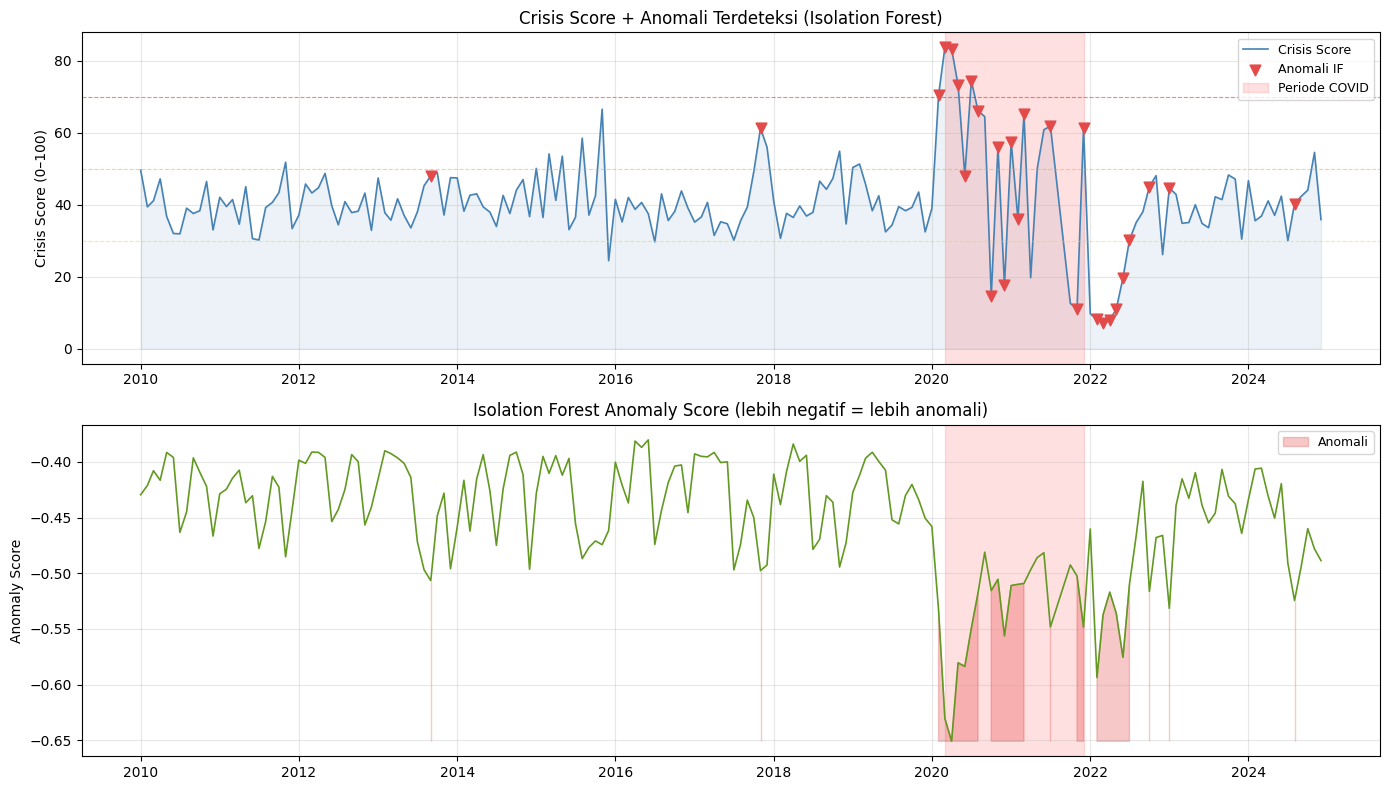

✅ Plot disimpan ke data/final/isolation_forest_results.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Crisis score + anomali markers
ax1 = axes[0]
months_dt = pd.to_datetime(df_model['month'].astype(str))
ax1.plot(months_dt, df_model['crisis_score_100'], color='steelblue', linewidth=1.2, label='Crisis Score')
ax1.fill_between(months_dt, 0, df_model['crisis_score_100'], alpha=0.1, color='steelblue')

# Anomali markers
anomali_mask = df_model['iso_anomaly'] == 1
ax1.scatter(months_dt[anomali_mask], df_model['crisis_score_100'][anomali_mask],
            color='#E24B4A', s=60, zorder=5, label='Anomali IF', marker='v')

# COVID shading
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-12-01')
ax1.axvspan(covid_start, covid_end, alpha=0.12, color='red', label='Periode COVID')
ax1.axhline(70, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.axhline(50, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.axhline(30, color='gold', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.set_title('Crisis Score + Anomali Terdeteksi (Isolation Forest)', fontsize=12)
ax1.set_ylabel('Crisis Score (0–100)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: Anomaly score timeline
ax2 = axes[1]
ax2.plot(months_dt, df_model['iso_score'], color='#639922', linewidth=1.2)
ax2.fill_between(months_dt, df_model['iso_score'].min(), df_model['iso_score'],
                 where=df_model['iso_anomaly']==1, alpha=0.3, color='#E24B4A', label='Anomali')
ax2.axvspan(covid_start, covid_end, alpha=0.12, color='red')
ax2.set_title('Isolation Forest Anomaly Score (lebih negatif = lebih anomali)', fontsize=12)
ax2.set_ylabel('Anomaly Score')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('data/final', exist_ok=True)
plt.savefig('data/final/isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot disimpan ke data/final/isolation_forest_results.png')

## 6. Model 2 — Random Forest Classifier (Crisis Level Prediction)

**Random Forest** memprediksi level krisis (AMAN/WASPADA/SIAGA/KRISIS) berdasarkan semua fitur.
Menggunakan **TimeSeriesSplit** untuk evaluasi — tidak boleh random split pada data time series.

In [10]:
# ════════════════════════════════════════════════════════════════
# SOLUSI: Custom Walk-Forward CV yang COVID-aware
# ════════════════════════════════════════════════════════════════
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score 
import numpy as np

# ── Strategi 1: min_train_size agar setiap fold punya konteks cukup ──
# Pastikan training set minimal 60% data (≥107 baris) sebelum test dimulai
n_total     = len(X_scaled)
min_train   = int(n_total * 0.60)   # 107 baris ≈ sampai ~2018
test_size   = int(n_total * 0.10)   # ~18 baris per fold ≈ 1.5 tahun
gap         = 1                      # 1 bulan gap — cegah leakage seasonal

print('=== CUSTOM WALK-FORWARD CV (COVID-aware) ===')
print(f'Total data   : {n_total} baris')
print(f'Min training : {min_train} baris (dari awal)')
print(f'Test size    : {test_size} baris per fold')
print(f'Gap          : {gap} bulan')
print()

# Buat manual fold indices
fold_results = []
fold_num = 1

train_end = min_train
while train_end + gap + test_size <= n_total:
    test_start = train_end + gap
    test_end   = test_start + test_size

    train_idx = np.arange(0, train_end)
    test_idx  = np.arange(test_start, test_end)

    # Distribusi kelas di tiap fold
    train_labels = [LABEL_ORDER[i] for i in y[train_idx]]
    test_labels  = [LABEL_ORDER[i] for i in y[test_idx]]

    # Cek apakah semua kelas tersedia di training
    train_classes = set(y[train_idx])
    test_classes  = set(y[test_idx])
    coverage      = test_classes.issubset(train_classes)

    # Fit & evaluate
    rf_cv = RandomForestClassifier(
        n_estimators=300, max_depth=8,
        min_samples_split=5, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_cv.fit(X_scaled[train_idx], y[train_idx])
    y_fold_pred = rf_cv.predict(X_scaled[test_idx])

    acc = accuracy_score(y[test_idx], y_fold_pred)
    f1  = f1_score(y[test_idx], y_fold_pred, average='macro', zero_division=0)

    # Label periode
    period_start = str(months[test_start])[:7]
    period_end   = str(months[test_end - 1])[:7]

    fold_results.append({
        'fold': fold_num,
        'train_n': len(train_idx),
        'test_n': len(test_idx),
        'period': f'{period_start} → {period_end}',
        'coverage': '✅' if coverage else '⚠️ partial',
        'accuracy': acc,
        'f1_macro': f1
    })

    print(f'Fold {fold_num}: train[0–{train_end}] test[{test_start}–{test_end}]')
    print(f'  Periode  : {period_start} → {period_end}')
    print(f'  Kelas OK : {"✅ semua kelas tercover" if coverage else "⚠️  test punya kelas baru!"}')
    print(f'  Accuracy : {acc:.3f}   F1 Macro: {f1:.3f}')
    print()

    train_end += test_size
    fold_num  += 1

# Ringkasan
accs = [r['accuracy'] for r in fold_results]
f1s  = [r['f1_macro'] for r in fold_results]
print('═' * 55)
print(f'Mean Accuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}')
print(f'Mean F1 Macro : {np.mean(f1s):.3f} ± {np.std(f1s):.3f}')
print(f'Jumlah fold   : {len(fold_results)}')

# ── Simpan hasil sebagai numpy array (dipakai Cell ringkasan) ──
cv_scores = np.array(accs)
cv_f1     = np.array(f1s)

print()
print('═' * 55)
print(f'Walk-Forward CV Summary ({len(fold_results)} fold):')
print(f'  Mean Accuracy  : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'  Mean F1 Macro  : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print()
print('Detail per fold:')
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['period']} | Acc={r['accuracy']:.3f} | F1={r['f1_macro']:.3f} | {r['coverage']}")


=== CUSTOM WALK-FORWARD CV (COVID-aware) ===
Total data   : 178 baris
Min training : 106 baris (dari awal)
Test size    : 17 baris per fold
Gap          : 1 bulan

Fold 1: train[0–106] test[107–124]
  Periode  : 2018-12 → 2020-04
  Kelas OK : ⚠️  test punya kelas baru!
  Accuracy : 0.706   F1 Macro: 0.308

Fold 2: train[0–123] test[124–141]
  Periode  : 2020-05 → 2021-11
  Kelas OK : ✅ semua kelas tercover
  Accuracy : 0.118   F1 Macro: 0.103

Fold 3: train[0–140] test[141–158]
  Periode  : 2021-12 → 2023-04
  Kelas OK : ✅ semua kelas tercover
  Accuracy : 0.647   F1 Macro: 0.472

Fold 4: train[0–157] test[158–175]
  Periode  : 2023-05 → 2024-09
  Kelas OK : ✅ semua kelas tercover
  Accuracy : 1.000   F1 Macro: 1.000

═══════════════════════════════════════════════════════
Mean Accuracy : 0.618 ± 0.318
Mean F1 Macro : 0.471 ± 0.333
Jumlah fold   : 4

═══════════════════════════════════════════════════════
Walk-Forward CV Summary (4 fold):
  Mean Accuracy  : 0.618 ± 0.318
  Mean F1 Macr

### 6.1 Confusion Matrix

In [11]:
from sklearn.preprocessing import LabelEncoder

# Definisi ulang le & label_order — konsisten dengan LABEL_ORDER
le = LabelEncoder()
le.classes_ = np.array(LABEL_ORDER)   # fit manual, urutan sudah benar

# Alias lowercase untuk kompatibilitas cell-cell lama di notebook
label_order = LABEL_ORDER             # ['AMAN', 'WASPADA', 'SIAGA', 'KRISIS']

# Verifikasi
print('LabelEncoder classes :', le.classes_)
print('label_order          :', label_order)
print()
print('Test inverse_transform:', le.inverse_transform([0, 1, 2, 3]))

# ── Train FINAL RF model pada semua data (setelah CV selesai evaluasi) ──
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    min_samples_split=5, min_samples_leaf=3,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_scaled, y)

# Prediksi pada semua data (in-sample) untuk evaluasi & penyimpanan
y_pred        = rf_model.predict(X_scaled)
y_pred_labels = le.inverse_transform(y_pred)

print()
print('=== FINAL RF MODEL — dilatih pada semua data ===')
print(f'Sampel training : {len(X_scaled)}')
print(f'Training Accuracy: {accuracy_score(y, y_pred)*100:.1f}%')
print()
print(classification_report(le.inverse_transform(y), y_pred_labels, zero_division=0))


LabelEncoder classes : ['AMAN' 'WASPADA' 'SIAGA' 'KRISIS']
label_order          : ['AMAN', 'WASPADA', 'SIAGA', 'KRISIS']

Test inverse_transform: ['AMAN' 'WASPADA' 'SIAGA' 'KRISIS']

=== FINAL RF MODEL — dilatih pada semua data ===
Sampel training : 178
Training Accuracy: 99.4%

              precision    recall  f1-score   support

        AMAN       0.86      1.00      0.92         6
      KRISIS       1.00      1.00      1.00         5
       SIAGA       1.00      1.00      1.00        31
     WASPADA       1.00      0.99      1.00       136

    accuracy                           0.99       178
   macro avg       0.96      1.00      0.98       178
weighted avg       1.00      0.99      0.99       178



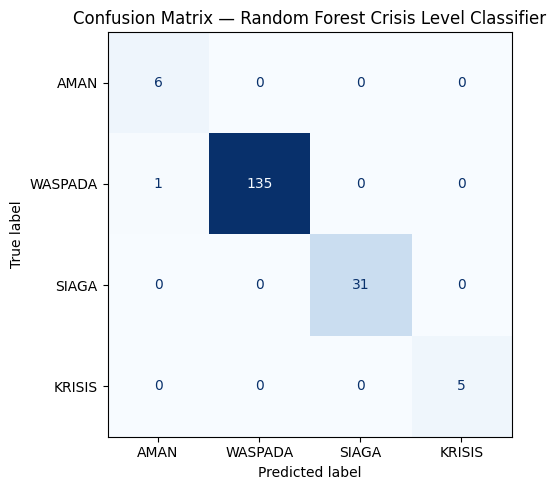

✅ Confusion matrix disimpan


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(le.inverse_transform(y), y_pred_labels, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest Crisis Level Classifier', fontsize=12)
plt.tight_layout()
plt.savefig('data/final/confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix disimpan')

## 6b. Baseline Model Comparison

RF dibandingkan model sederhana — jika RF jauh lebih baik, kompleksitas model **justified**.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree        import DecisionTreeClassifier
from sklearn.dummy       import DummyClassifier
from sklearn.metrics     import f1_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print('=== BASELINE MODEL COMPARISON ===')
print()

# Split terakhir dari TimeSeriesSplit
tscv_eval = TimeSeriesSplit(n_splits=5)
splits    = list(tscv_eval.split(X_scaled, y))
tr_idx, te_idx = splits[-1]
X_tr, X_te = X_scaled[tr_idx], X_scaled[te_idx]
y_tr, y_te = y[tr_idx],        y[te_idx]

baselines = {
    'Dummy (Most Frequent)': DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree (d=5)'  : DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest ✓'      : rf_model,
}

print(f'  {"Model":30s} | {"Accuracy":>8s} | {"Macro-F1":>8s} | {"Wgt-F1":>8s}')
print(f'  {"-"*30}-+-{"-"*8}-+-{"-"*8}-+-{"-"*8}')

best_f1, best_name = 0, ''
for name, model in baselines.items():
    model.fit(X_tr, y_tr)
    yp   = model.predict(X_te)
    acc  = (yp == y_te).mean()
    mf1  = f1_score(y_te, yp, average='macro',    zero_division=0)
    wf1  = f1_score(y_te, yp, average='weighted', zero_division=0)
    marker = ' ← BEST' if name == 'Random Forest ✓' else ''
    print(f'  {name:30s} | {acc:8.3f} | {mf1:8.3f} | {wf1:8.3f}{marker}')
    if mf1 > best_f1: best_f1, best_name = mf1, name

print()
print(f'  🏆 Best Macro-F1: {best_name} ({best_f1:.3f})')
print()

# RF Full Report
print('=== RF Classification Report (test split terakhir) ===')
rf_model.fit(X_tr, y_tr)
yp_rf = rf_model.predict(X_te)
print(classification_report(le.inverse_transform(y_te), le.inverse_transform(yp_rf), zero_division=0))

# ROC-AUC multiclass
try:
    y_proba = rf_model.predict_proba(X_te)
    roc_auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
    print(f'ROC-AUC (macro OvR): {roc_auc:.4f}')
except Exception as e:
    print(f'ROC-AUC: tidak tersedia — {e}')


=== BASELINE MODEL COMPARISON ===

  Model                          | Accuracy | Macro-F1 |   Wgt-F1
  -------------------------------+----------+----------+---------
  Dummy (Most Frequent)          |    0.931 |    0.321 |    0.898
  Logistic Regression            |    0.552 |    0.390 |    0.653
  Decision Tree (d=5)            |    0.931 |    0.321 |    0.898
  Random Forest ✓                |    0.966 |    0.661 |    0.949 ← BEST

  🏆 Best Macro-F1: Random Forest ✓ (0.661)

=== RF Classification Report (test split terakhir) ===
              precision    recall  f1-score   support

        AMAN       0.00      0.00      0.00         1
       SIAGA       1.00      1.00      1.00         1
     WASPADA       0.96      1.00      0.98        27

    accuracy                           0.97        29
   macro avg       0.65      0.67      0.66        29
weighted avg       0.93      0.97      0.95        29

ROC-AUC: tidak tersedia — Number of classes in y_true not equal to the number of 

### 6.2 Feature Importance

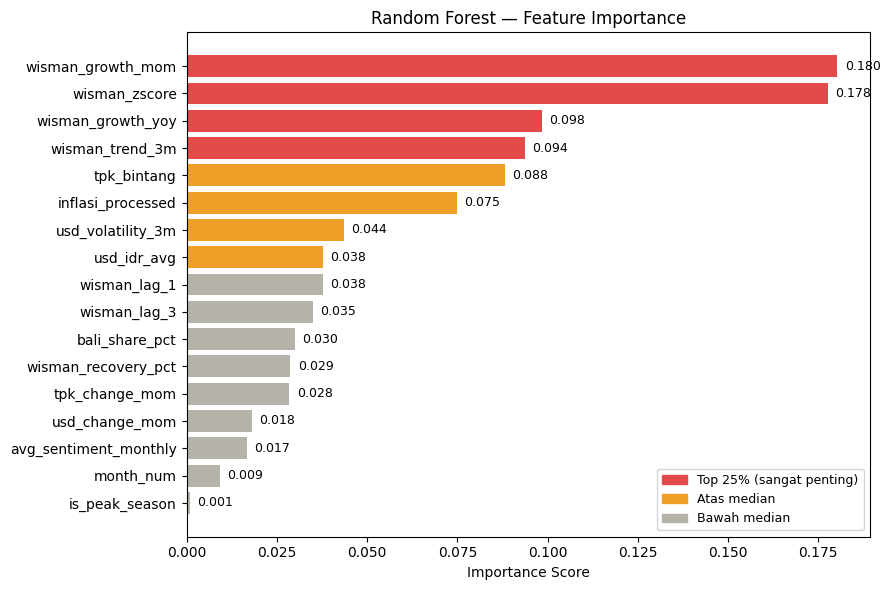

Top 5 fitur terpenting:
              feature  importance
0   wisman_growth_mom    0.180305
2       wisman_zscore    0.177705
1   wisman_growth_yoy    0.098429
15    wisman_trend_3m    0.093754
6         tpk_bintang    0.088310


In [14]:
# Feature importance dari Random Forest
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E24B4A' if v > fi_df['importance'].quantile(0.75) else
          '#EF9F27' if v > fi_df['importance'].median() else
          '#B4B2A9' for v in fi_df['importance']]

bars = ax.barh(fi_df['feature'], fi_df['importance'], color=colors)
ax.set_title('Random Forest — Feature Importance', fontsize=12)
ax.set_xlabel('Importance Score')

# Annotate
for bar, val in zip(bars, fi_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#E24B4A', label='Top 25% (sangat penting)'),
    mpatches.Patch(color='#EF9F27', label='Atas median'),
    mpatches.Patch(color='#B4B2A9', label='Bawah median'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('data/final/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 fitur terpenting:')
print(fi_df.tail(5)[['feature','importance']].sort_values('importance', ascending=False).to_string())

## 7. SHAP — Explainability

**SHAP (SHapley Additive exPlanations)** menjelaskan *mengapa* model membuat prediksi tertentu.
Untuk setiap prediksi, SHAP menunjukkan kontribusi positif/negatif dari setiap fitur.

Shape SHAP values: (178, 17, 4)
Classes: [np.str_('AMAN'), np.str_('WASPADA'), np.str_('SIAGA'), np.str_('KRISIS')]
SHAP array shape: (178, 17, 4)
Shape SHAP untuk KRISIS: (178, 17)
Shape X_scaled: (178, 17)



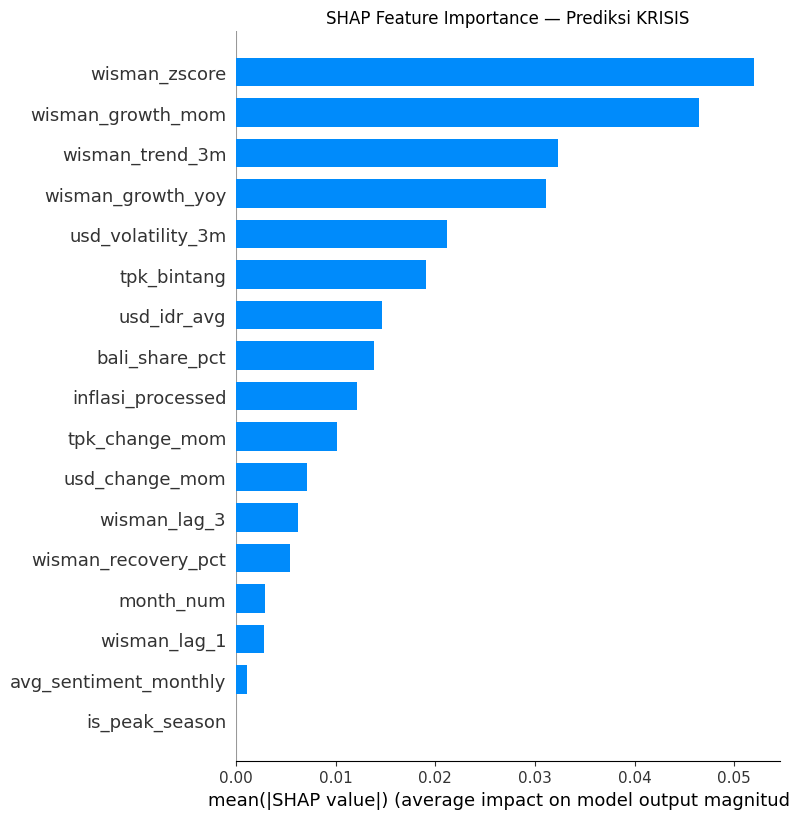

✅ SHAP summary plot disimpan


In [15]:
try:
    import shap

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_scaled)

    print('Shape SHAP values:', np.array(shap_values).shape)
    print('Classes:', list(le.classes_))

    # ✅ FIX: Handle dua kemungkinan format output SHAP
    # Format lama: list of arrays [n_classes][n_samples, n_features]
    # Format baru: single array [n_samples, n_features, n_classes]
    shap_arr = np.array(shap_values)
    print('SHAP array shape:', shap_arr.shape)

    krisis_idx = list(le.classes_).index('KRISIS')

    if shap_arr.ndim == 3:
        # Format baru: (n_samples, n_features, n_classes)
        shap_krisis = shap_arr[:, :, krisis_idx]
    else:
        # Format lama: (n_classes, n_samples, n_features)
        shap_krisis = shap_arr[krisis_idx]

    print('Shape SHAP untuk KRISIS:', shap_krisis.shape)
    print('Shape X_scaled:', X_scaled.shape)
    print()

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_krisis,
        X_scaled,
        feature_names=FEATURES,
        plot_type='bar',
        show=False
    )
    plt.title('SHAP Feature Importance — Prediksi KRISIS', fontsize=12)
    plt.tight_layout()
    plt.savefig('data/final/shap_summary_krisis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ SHAP summary plot disimpan')

except ImportError:
    print('⚠️  SHAP tidak tersedia. Install dengan: pip install shap')

### 7.1 SHAP Beeswarm Plot — Detail Kontribusi Fitur

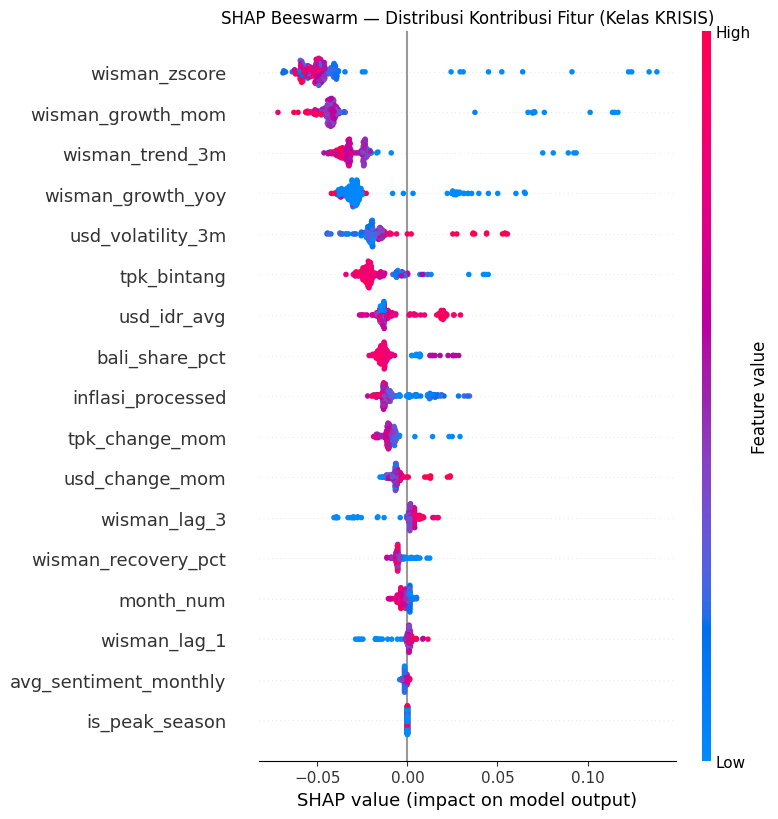

✅ SHAP beeswarm disimpan

=== SHAP ANALISIS: Maret 2020 (puncak krisis) ===
                  feature  shap_value  feature_value
2           wisman_zscore      0.1342        -2.3761
0       wisman_growth_mom      0.1168        -0.0955
15        wisman_trend_3m      0.0924        -3.8680
1       wisman_growth_yoy      0.0654        -0.1475
4       usd_volatility_3m      0.0547         4.6140
8       inflasi_processed      0.0344        -0.6551
9          bali_share_pct      0.0285        -1.0156
3             usd_idr_avg      0.0259         1.0167
7          tpk_change_mom      0.0249        -3.3329
5          usd_change_mom      0.0237         2.9682
14           wisman_lag_3      0.0165         1.4102
6             tpk_bintang      0.0112        -1.6800
13           wisman_lag_1      0.0088         0.2680
11              month_num      0.0051        -1.0038
16    wisman_recovery_pct      0.0043        -0.9084
12         is_peak_season      0.0000        -0.5730
10  avg_sentiment_month

In [16]:
try:
    import shap

    # ✅ FIX: Pakai shap_krisis yang sudah difix di cell sebelumnya
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_krisis,        # ← ganti dari shap_krisis
        X_scaled,
        feature_names=FEATURES,
        plot_type='dot',
        show=False
    )
    plt.title('SHAP Beeswarm — Distribusi Kontribusi Fitur (Kelas KRISIS)', fontsize=12)
    plt.tight_layout()
    plt.savefig('data/final/shap_beeswarm_krisis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ SHAP beeswarm disimpan')

    # Analisis bulan Mar 2020
    mar2020_idx = df_model[df_model['month'] == '2020-03'].index
    if len(mar2020_idx) > 0:
        idx_in_model = df_model.index.get_loc(mar2020_idx[0])
        print()
        print('=== SHAP ANALISIS: Maret 2020 (puncak krisis) ===')
        # ✅ FIX: pakai shap_krisis bukan shap_krisis
        krisis_shap_row = shap_krisis[idx_in_model]
        shap_explain = pd.DataFrame({
            'feature': FEATURES,
            'shap_value': krisis_shap_row,
            'feature_value': X_scaled[idx_in_model]
        }).sort_values('shap_value', ascending=False)
        print(shap_explain.round(4).to_string())

except ImportError:
    print('⚠️  Skip SHAP beeswarm — SHAP tidak terinstall')

## 8. Gabungkan Semua Prediksi

In [17]:
# Gabungkan semua prediksi ke satu dataframe
df_model['rf_predicted_level'] = y_pred_labels
df_model['rf_correct'] = (df_model['rf_predicted_level'] == df_model[TARGET])

# Hitung confidence (max probability dari RF)
y_proba = rf_model.predict_proba(X_scaled)
df_model['rf_confidence'] = y_proba.max(axis=1)

# Mapping probabilitas per kelas
for i, cls in enumerate(le.classes_):
    df_model[f'prob_{cls.lower()}'] = y_proba[:, i]

print('=== RINGKASAN PREDIKSI ===')
print(f'Accuracy keseluruhan: {accuracy_score(y, y_pred)*100:.1f}%')
print()
print('Prediksi per periode kritis:')
kritis_periods = df_model[df_model[TARGET].isin(['SIAGA','KRISIS'])]
print(kritis_periods[['month','crisis_score_100',TARGET,'rf_predicted_level','rf_confidence']].to_string())

=== RINGKASAN PREDIKSI ===
Accuracy keseluruhan: 99.4%

Prediksi per periode kritis:
       month  crisis_score_100 crisis_level rf_predicted_level  rf_confidence
22   2011-11         51.769859        SIAGA              SIAGA       0.509840
60   2015-01         50.067171        SIAGA              SIAGA       0.623207
62   2015-03         54.096131        SIAGA              SIAGA       0.739003
64   2015-05         53.469674        SIAGA              SIAGA       0.674820
67   2015-08         58.446355        SIAGA              SIAGA       0.684223
70   2015-11         66.506344        SIAGA              SIAGA       0.739972
94   2017-11         61.228565        SIAGA              SIAGA       0.646756
95   2017-12         55.961307        SIAGA              SIAGA       0.673981
106  2018-11         54.851169        SIAGA              SIAGA       0.754305
108  2019-01         50.320305        SIAGA              SIAGA       0.708348
109  2019-02         51.276583        SIAGA              

## 9. Simpan Model & Output

In [18]:
os.makedirs('data/final', exist_ok=True)
os.makedirs('data/models', exist_ok=True)

# Simpan model
joblib.dump(iso_forest, 'data/models/model_isolation_forest.pkl')
joblib.dump(rf_model,   'data/models/model_random_forest.pkl')
joblib.dump(scaler,     'data/models/scaler.pkl')
joblib.dump(le,         'data/models/label_encoder.pkl')

print('✅ Model disimpan ke data/models/')
print('   - model_isolation_forest.pkl')
print('   - model_random_forest.pkl')
print('   - scaler.pkl')
print('   - label_encoder.pkl')

# Simpan prediksi final
output_cols = [
    'month', 'wisman', 'tpk_bintang', 'inflasi_processed',
    'usd_idr_avg', 'avg_sentiment_monthly',
    'bali_share_pct', 'wisman_zscore',   # ✅ FIX: dibutuhkan dashboard
    'crisis_score_100', TARGET, 'rf_predicted_level', 'rf_confidence',
    'prob_aman', 'prob_waspada', 'prob_siaga', 'prob_krisis',
    'iso_anomaly', 'iso_score'
]
# ✅ FIX: merge kolom extra dari master jika belum ada di df_model
extra_needed = ['bali_share_pct', 'wisman_zscore']
for col in extra_needed:
    if col not in df_model.columns and col in df.columns:  # 'df' = master parquet dari NB04
        master_col = df[['month', col]].copy()
        master_col['month'] = master_col['month'].astype(str)
        df_model = df_model.merge(master_col, on='month', how='left')

output_cols = [c for c in output_cols if c in df_model.columns]
predictions_df = df_model[output_cols].copy()
predictions_df.to_csv('data/final/predictions_final.csv', index=False)

print()
print('✅ Prediksi disimpan ke data/final/predictions_final.csv')
print(f'   Shape: {predictions_df.shape}')

✅ Model disimpan ke data/models/
   - model_isolation_forest.pkl
   - model_random_forest.pkl
   - scaler.pkl
   - label_encoder.pkl

✅ Prediksi disimpan ke data/final/predictions_final.csv
   Shape: (178, 18)


## 10. Visualisasi Akhir — Crisis Timeline dengan Prediksi

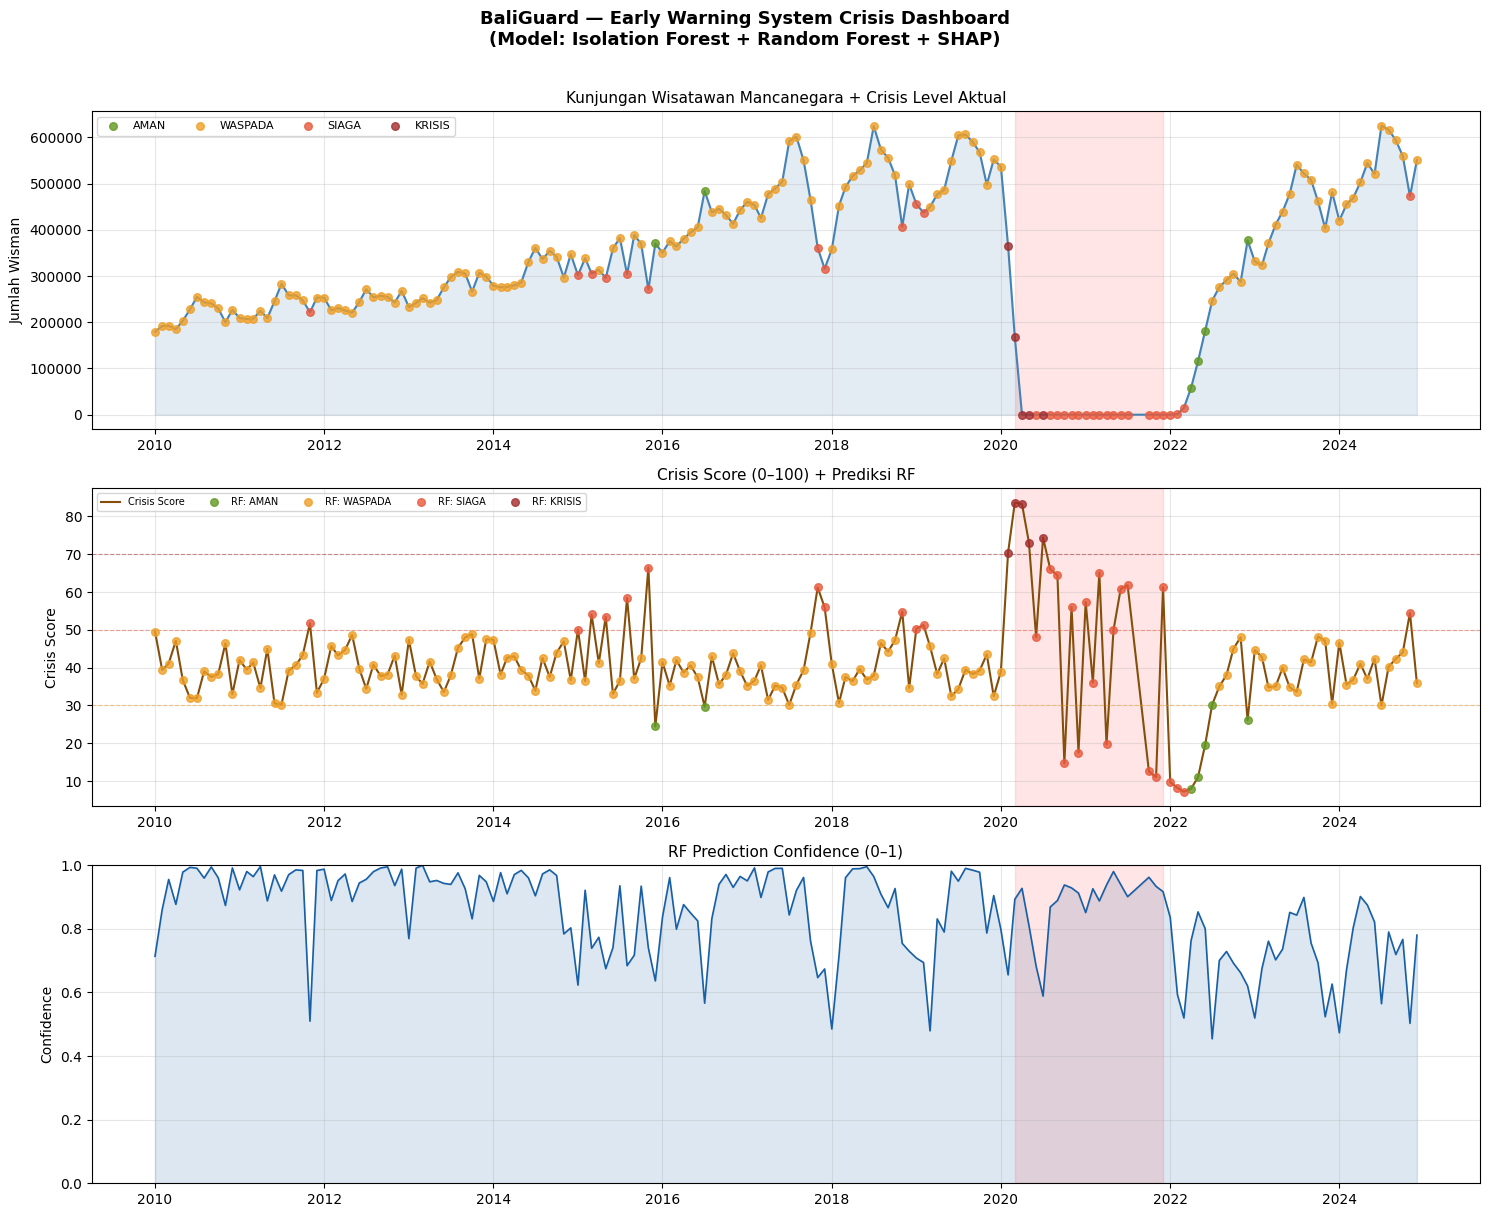

✅ Plot final disimpan ke data/final/crisis_timeline_final.png


In [19]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
months_dt = pd.to_datetime(df_model['month'].astype(str))

color_map = {'AMAN': '#639922', 'WASPADA': '#EF9F27', 'SIAGA': '#E8593C', 'KRISIS': '#A32D2D'}

# Plot 1: Wisman dengan crisis level
ax1 = axes[0]
ax1.plot(months_dt, df_model['wisman'], color='steelblue', linewidth=1.5)
ax1.fill_between(months_dt, 0, df_model['wisman'], alpha=0.15, color='steelblue')
for level, color in color_map.items():
    mask = df_model[TARGET] == level
    ax1.scatter(months_dt[mask], df_model['wisman'][mask],
                color=color, s=30, zorder=5, label=level, alpha=0.8)
ax1.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax1.set_title('Kunjungan Wisatawan Mancanegara + Crisis Level Aktual', fontsize=11)
ax1.set_ylabel('Jumlah Wisman')
ax1.legend(fontsize=8, ncol=4)
ax1.grid(alpha=0.3)

# Plot 2: Crisis score + RF prediction
ax2 = axes[1]
ax2.plot(months_dt, df_model['crisis_score_100'], color='#854F0B', linewidth=1.5, label='Crisis Score')
for level, color in color_map.items():
    mask = df_model['rf_predicted_level'] == level
    ax2.scatter(months_dt[mask], df_model['crisis_score_100'][mask],
                color=color, s=30, zorder=5, alpha=0.8, label=f'RF: {level}')
ax2.axhline(70, color='#A32D2D', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(50, color='#E8593C', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axhline(30, color='#EF9F27', linestyle='--', alpha=0.5, linewidth=0.8)
ax2.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax2.set_title('Crisis Score (0–100) + Prediksi RF', fontsize=11)
ax2.set_ylabel('Crisis Score')
ax2.legend(fontsize=7, ncol=5)
ax2.grid(alpha=0.3)

# Plot 3: RF confidence
ax3 = axes[2]
ax3.plot(months_dt, df_model['rf_confidence'], color='#185FA5', linewidth=1.2)
ax3.fill_between(months_dt, 0, df_model['rf_confidence'], alpha=0.15, color='#185FA5')
ax3.axvspan(pd.Timestamp('2020-03'), pd.Timestamp('2021-12'), alpha=0.1, color='red')
ax3.set_title('RF Prediction Confidence (0–1)', fontsize=11)
ax3.set_ylabel('Confidence')
ax3.set_ylim(0, 1)
ax3.grid(alpha=0.3)

plt.suptitle('BaliGuard — Early Warning System Crisis Dashboard\n(Model: Isolation Forest + Random Forest + SHAP)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/final/crisis_timeline_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot final disimpan ke data/final/crisis_timeline_final.png')

## 11. Ringkasan Model

In [20]:
print('=' * 55)
print('  BALIGUARD — RINGKASAN MODEL NB05')
print('=' * 55)
print()
print('📊 Dataset:')
print(f'   {len(df_model)} baris × {len(FEATURES)} fitur')
print(f'   Periode: {df_model["month"].min()} → {df_model["month"].max()}')
print()
print('🌲 Isolation Forest:')
print(f'   Contamination: 15%')
print(f'   Anomali terdeteksi: {df_model["iso_anomaly"].sum()} bulan')
covid_detected = df_model[
    df_model['month'].between('2020-01','2021-12') &
    (df_model['iso_anomaly']==1)
]
print(f'   COVID months terdeteksi: {len(covid_detected)}/{len(df_model[df_model["month"].between("2020-01","2021-12")])}')
print()
print('🌳 Random Forest Classifier:')
acc = accuracy_score(y, y_pred) * 100
print(f'   Accuracy (training): {acc:.1f}%')
print(f'   CV Accuracy (walk-forward CV)       : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'   CV F1 Macro  (walk-forward CV)       : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print(f'   n_estimators: 300, max_depth: 8')
print(f'   class_weight: balanced')
print()
print('💾 Output tersimpan:')
print('   data/models/model_isolation_forest.pkl')
print('   data/models/model_random_forest.pkl')
print('   data/models/scaler.pkl')
print('   data/models/label_encoder.pkl')
print('   data/final/predictions_final.csv')
print()
print('🎯 Langkah selanjutnya: NB06 — LLM Narrative Engine + Dashboard Streamlit')
print('=' * 55)

  BALIGUARD — RINGKASAN MODEL NB05

📊 Dataset:
   178 baris × 17 fitur
   Periode: 2010-01 → 2024-12

🌲 Isolation Forest:
   Contamination: 15%
   Anomali terdeteksi: 27 bulan
   COVID months terdeteksi: 16/22

🌳 Random Forest Classifier:
   Accuracy (training): 99.4%
   CV Accuracy (walk-forward CV)       : 0.618 ± 0.318
   CV F1 Macro  (walk-forward CV)       : 0.471 ± 0.333
   n_estimators: 300, max_depth: 8
   class_weight: balanced

💾 Output tersimpan:
   data/models/model_isolation_forest.pkl
   data/models/model_random_forest.pkl
   data/models/scaler.pkl
   data/models/label_encoder.pkl
   data/final/predictions_final.csv

🎯 Langkah selanjutnya: NB06 — LLM Narrative Engine + Dashboard Streamlit
